# YZTA 5.0 Datathon - Veri Seti Tanımı

Bu yarışmada katılımcılardan, bireylerin uyku düzeni, yaşam alışkanlıkları ve günlük durumlarına ait değişkenleri kullanarak **bilişsel performans skoru** değişkenini tahmin etmeleri beklenmektedir. 

* **Problem Türü:** Regresyon
* **Hedef Değişken:** Sürekli sayısal bir değer (Bilişsel Performans Skoru)
* **Amaç:** Eğitim verisi üzerinden değişkenler arasındaki ilişkileri öğrenerek test verisi üzerindeki bireyler için doğru tahminler üretmektir.

Yarışma kapsamında hem sayısal hem de kategorik değişkenler birlikte sunulmakta olup, başarılı bir model geliştirmek için veri ön işleme, eksik değer yönetimi ve uygun model seçimi kritik önem taşımaktadır.

---

## Dosyalar

* **`train.csv`**: Eğitim verisi; özellikler ve hedef değişken birlikte bulunur.
* **`test_x.csv`**: Katılımcıların tahmin üretmesi için kullanılacak test özelliklerini içerir.
* **`sample_submission.csv`**: Gönderim formatını gösteren örnek dosyadır. `id` ve hedef sütun alanlarını içerir.

---

## Sütunlar (Değişkenler)

* **`id`**: Her satır için benzersiz kimlik numarasını gösterir.
* **`yas`**: Katılımcının yaş bilgisini içerir.
* **`cinsiyet`**: Katılımcının cinsiyetini belirtir.
* **`meslek`**: Katılımcının meslek grubunu ifade eder.
* **`vucut_kitle_indeksi`**: Katılımcının vücut kitle indeksi değerini gösterir.
* **`ulke`**: Katılımcının yaşadığı veya ilişkilendirildiği ülke bilgisini içerir.
* **`rem_yuzdesi`**: REM uykusunun toplam uyku içindeki oranını gösterir.
* **`derin_uyku_yuzdesi`**: Derin uykunun toplam uyku içindeki oranını ifade eder.
* **`uykuya_dalma_suresi_dk`**: Katılımcının uykuya dalması için geçen süreyi dakika cinsinden verir.
* **`gecelik_uyanma_sayisi`**: Gece boyunca yaşanan uyanma sayısını gösterir.
* **`uyku_oncesi_kafein_mg`**: Uyku öncesinde alınan kafein miktarını miligram cinsinden içerir.
* **`uyku_oncesi_ekran_suresi_dk`**: Uyku öncesinde ekran karşısında geçirilen süreyi dakika cinsinden gösterir.
* **`gunluk_adim_sayisi`**: Katılımcının o gün attığı toplam adım sayısını verir.
* **`sekerleme_suresi_dk`**: Gün içinde yapılan şekerlemenin süresini dakika cinsinden ifade eder.
* **`stres_skoru`**: Katılımcının stres düzeyini temsil eden sayısal bir skordur.
* **`gunluk_calisma_saati`**: Katılımcının o gün çalıştığı toplam saat miktarını gösterir.
* **`kronotip`**: Katılımcının biyolojik ritim veya uyku eğilimi tipini ifade eder.
* **`ruh_sagligi_durumu`**: Katılımcının ruh sağlığı durumuna ilişkin kategorik bilgiyi içerir.
* **`dinlenik_nabiz_bpm`**: Dinlenme halindeki nabız değerini dakika başına atım sayısı olarak verir.
* **`oda_sicakligi_celsius`**: Uyku ortamının sıcaklığını santigrat derece cinsinden gösterir.
* **`hafta_sonu_uyku_farki_saat`**: Hafta sonu uyku süresindeki değişimi saat cinsinden ifade eder.
* **`mevsim`**: Gözlemin ait olduğu mevsim bilgisini içerir.
* **`gun_tipi`**: Gözlemin hafta içi mi yoksa hafta sonu mu olduğunu belirtir.
* **`bilissel_performans_skoru`**: Tahmin edilmesi gereken hedef değişkendir ve bireyin bilişsel performans düzeyini sayısal olarak temsil eder.

# Part-1: Keşifçi Veri Analizi ve Veri Görselleştirme

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv('train.csv')
test = pd.read_csv('test_x.csv')
sample_sub = pd.read_csv('sample_submission.csv')

print('Veriler başarıyla yüklendi.')

Veriler başarıyla yüklendi.


In [2]:
print('Eğitim (Train) Verisi')
print("Satır sayısı (Gözlem Sayısı) :", train.shape[0])
print("Sütun sayısı (Değişken Sayısı) :", train.shape[1])

Eğitim (Train) Verisi
Satır sayısı (Gözlem Sayısı) : 56000
Sütun sayısı (Değişken Sayısı) : 24


In [3]:
print('Eğitim Verisinden İlk 5 Satır:')
display(train.head())

Eğitim Verisinden İlk 5 Satır:


,id,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,...,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi,bilissel_performans_skoru
0,1,34,Erkek,Saglik Personeli,31.470103,Cin,14.431210,14.645436,27,7,...,9.922976,10.045274,Sabah insani,Anksiyete ve depresyon,78,18.962436,-0.074140,Sonbahar-Kis,Hafta ici,0.136441
1,2,32,Kadin,Muhendis,30.981394,Amerika,21.771870,27.220360,20,4,...,6.626400,6.319245,Gece insani,Saglikli,76,21.225666,0.942672,Sonbahar-Kis,Hafta ici,5.848312
2,3,39,Erkek,Ev Hanimi,21.533898,Spain,18.178857,25.530104,33,7,...,6.093566,3.824463,Notr,Depresyon,66,18.482409,1.239886,Ilkbahar-Yaz,Hafta sonu,6.828276
3,4,40,Kadin,Egitimci,23.310749,Yeni Zelanda,21.438151,15.891188,21,2,...,3.168185,4.597316,Gece insani,Saglikli,60,21.862235,0.727695,Sonbahar-Kis,Hafta sonu,8.144649
4,5,36,Kadin,NaN,NaN,Portekiz,25.468018,16.356738,21,8,...,7.198574,3.189120,Notr,Anksiyete ve depresyon,74,19.223195,-0.223402,Sonbahar-Kis,Hafta ici,0.431423


In [4]:
print('--- Eğitim Seti Sütun Bilgileri ve Veri Tipleri ---\n')
print(train.info())

--- Eğitim Seti Sütun Bilgileri ve Veri Tipleri ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           56000 non-null  int64  
 1   yas                          56000 non-null  int64  
 2   cinsiyet                     56000 non-null  object 
 3   meslek                       54622 non-null  object 
 4   vucut_kitle_indeksi          54248 non-null  float64
 5   ulke                         56000 non-null  object 
 6   rem_yuzdesi                  56000 non-null  float64
 7   derin_uyku_yuzdesi           56000 non-null  float64
 8   uykuya_dalma_suresi_dk       56000 non-null  int64  
 9   gecelik_uyanma_sayisi        56000 non-null  int64  
 10  uyku_oncesi_kafein_mg        54537 non-null  float64
 11  uyku_oncesi_ekran_suresi_dk  56000 non-null  int64  
 12  gunluk_adim_sayisi   

In [5]:
print('\n--- Eğitim Seti Eksik Değer Bulunan Sütunlar ve Sayıları ---\n')
missing_values = train.isnull().sum()
missing_filtered = missing_values[missing_values > 0].sort_values(ascending=False)

if not missing_filtered.empty:
    display(pd.DataFrame({
        'Eksik Değer Sayısı': missing_filtered, 
        'Oran (%)': round((missing_filtered / len(train)) * 100, 2)
    }))
else:
    print('Eksik değer bulunmamaktadır.')


--- Eğitim Seti Eksik Değer Bulunan Sütunlar ve Sayıları ---



,Eksik Değer Sayısı,Oran (%)
kronotip,1968,3.51
vucut_kitle_indeksi,1752,3.13
stres_skoru,1715,3.06
uyku_oncesi_kafein_mg,1463,2.61
meslek,1378,2.46
ruh_sagligi_durumu,1096,1.96


In [6]:
print('\n--- Eğitim Seti Eksik Veri Sayıları ---\n')
print(train.isnull().sum())


--- Eğitim Seti Eksik Veri Sayıları ---

id                                0
yas                               0
cinsiyet                          0
meslek                         1378
vucut_kitle_indeksi            1752
ulke                              0
rem_yuzdesi                       0
derin_uyku_yuzdesi                0
uykuya_dalma_suresi_dk            0
gecelik_uyanma_sayisi             0
uyku_oncesi_kafein_mg          1463
uyku_oncesi_ekran_suresi_dk       0
gunluk_adim_sayisi                0
sekerleme_suresi_dk               0
stres_skoru                    1715
gunluk_calisma_saati              0
kronotip                       1968
ruh_sagligi_durumu             1096
dinlenik_nabiz_bpm                0
oda_sicakligi_celsius             0
hafta_sonu_uyku_farki_saat        0
mevsim                            0
gun_tipi                          0
bilissel_performans_skoru         0
dtype: int64


In [7]:
print('--- Sayısal Değişkenlerin Özeti ---\n')
display(train.describe())

print('\n--- Kategorik Değişkenlerin Özeti ---\n')
display(train.describe(include=['object']))

--- Sayısal Değişkenlerin Özeti ---



,id,yas,vucut_kitle_indeksi,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,uyku_oncesi_kafein_mg,uyku_oncesi_ekran_suresi_dk,gunluk_adim_sayisi,sekerleme_suresi_dk,stres_skoru,gunluk_calisma_saati,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,bilissel_performans_skoru
count,56000.000000,56000.000000,54248.000000,56000.000000,56000.000000,56000.000000,56000.000000,54537.000000,56000.000000,56000.000000,56000.000000,54285.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000
mean,28000.500000,34.714446,26.273651,20.233500,20.246063,20.107536,3.344929,42.110952,63.511446,7493.197554,15.432875,5.741407,7.156456,66.603214,20.531263,1.199050,5.913096
std,16165.951874,11.052508,4.495138,3.442993,4.300421,8.063278,2.034618,72.154159,44.590737,3462.699361,21.104672,1.624985,3.469731,7.353174,2.903317,0.790899,2.231759
min,1.000000,18.000000,16.000000,10.000000,5.000000,1.000000,0.000000,0.000000,2.000000,500.000000,0.000000,1.000000,0.000000,45.000000,15.000000,-1.000000,0.000000
25%,14000.750000,26.000000,23.175279,17.951724,17.337866,14.000000,2.000000,0.000000,30.000000,5042.000000,0.000000,4.761271,4.765942,62.000000,18.457240,0.660030,4.397431
50%,28000.500000,33.000000,26.225806,20.302218,20.292151,20.000000,3.000000,3.000000,51.000000,7426.000000,2.000000,5.824014,7.360860,67.000000,20.487456,1.202921,6.032249
75%,42000.250000,42.000000,29.321503,22.598180,23.227117,25.000000,5.000000,77.000000,84.000000,9876.000000,30.000000,6.837436,9.684531,72.000000,22.522152,1.743940,7.574980
max,56000.000000,69.000000,45.000000,30.000000,30.000000,58.000000,8.000000,400.000000,180.000000,20000.000000,115.000000,10.000000,18.000000,97.000000,28.000000,3.000000,10.000000



--- Kategorik Değişkenlerin Özeti ---



,cinsiyet,meslek,ulke,kronotip,ruh_sagligi_durumu,mevsim,gun_tipi
count,56000,54622,56000,54032,54904,56000,56000
unique,2,11,15,3,4,2,2
top,Kadin,Saglik Personeli,Ingiltere,Notr,Saglikli,Ilkbahar-Yaz,Hafta ici
freq,28676,9842,11324,24594,38365,28143,40052


In [8]:
# Kategorik değişkenlerin her bir sınıfının frekansı
for col in train.select_dtypes(include=['object']).columns:
    print(f"{col} sınıf sayıları ve frekansları:")
    print(train[col].value_counts())
    print("\n")

cinsiyet sınıf sayıları ve frekansları:
cinsiyet
Kadin    28676
Erkek    27324
Name: count, dtype: int64


meslek sınıf sayıları ve frekansları:
meslek
Saglik Personeli               9842
Ogrenci                        8132
Muhendis                       6533
Yonetici                       4454
Egitimci                       4395
Satis ve Pazarlama Calisani    3899
Serbest Calisan                3812
Lojistik Calisani              3811
Emekli                         3778
Ev Hanimi                      3224
Lawyer                         2742
Name: count, dtype: int64


ulke sınıf sayıları ve frekansları:
ulke
Ingiltere       11324
Cin              9989
Guney Kore       4459
Amerika          4447
Arjantin         3973
Fransa           3440
Ispanya          2823
Isvec            2798
Yeni Zelanda     2777
Portekiz         2204
South Korea      2189
Mexico           2165
Netherlands      1707
Spain            1139
Sweden            566
Name: count, dtype: int64


kronotip sınıf sayıları v

## Veri Görselleştirme

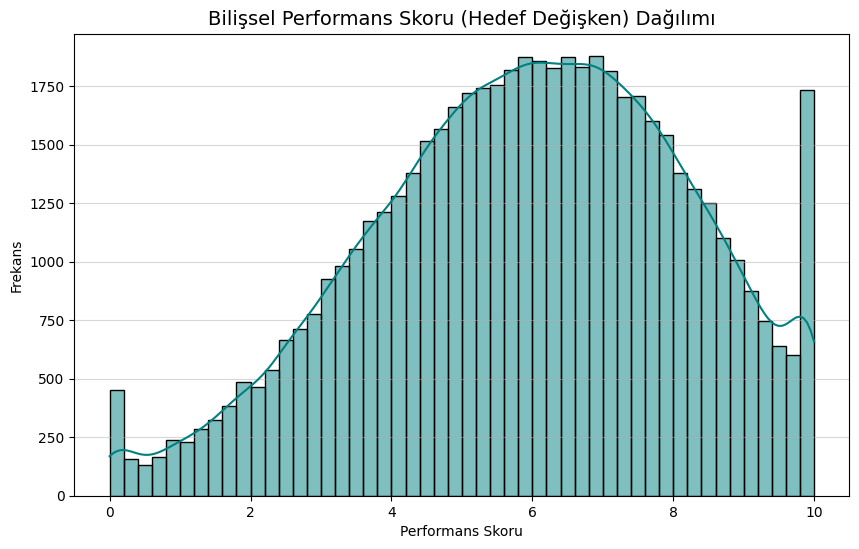

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(train['bilissel_performans_skoru'], kde=True, color='teal', bins=50)
plt.title('Bilişsel Performans Skoru (Hedef Değişken) Dağılımı', fontsize=14)
plt.xlabel('Performans Skoru')
plt.ylabel('Frekans')
plt.grid(axis='y', alpha=0.5)
plt.show()

**Yorum:**  
Bilişsel performans skoru dağılımı incelendiğinde verilerin büyük bölümünün orta ve yüksek skor aralığında yoğunlaştığı görülmektedir. Özellikle 5–8 aralığında belirgin bir yoğunluk bulunurken, düşük performans skorlarına sahip bireylerin sayısı daha sınırlıdır. Dağılım yaklaşık olarak normal yapıya yakın olsa da yüksek skor değerlerinde görülen yığılma, veri setinde yüksek bilişsel performansa sahip bireylerin daha fazla temsil edildiğini ve maksimum puan civarında tavan etkisi oluşabileceğini göstermektedir. Bu durum, uyku düzeni, stres seviyesi, ekran süresi ve günlük yaşam alışkanlıkları gibi değişkenlerin bilişsel performans üzerinde olumlu etkiler oluşturabileceğine işaret etmektedir.

### 1. Sayısal Değişkenler Arası Korelasyon Analizi (Heatmap)
Bu ısı haritası, veri setindeki sürekli sayısal değişkenlerin birbirleriyle olan doğrusal ilişkilerini (korelasyon) gösterir. +1'e yaklaşan değerler güçlü pozitif ilişkiyi, -1'e yaklaşan değerler ise güçlü negatif ilişkiyi temsil eder. Özellikle en sağ sütunda yer alan `bilissel_performans_skoru` ile olan ilişkilere odaklanacağız.

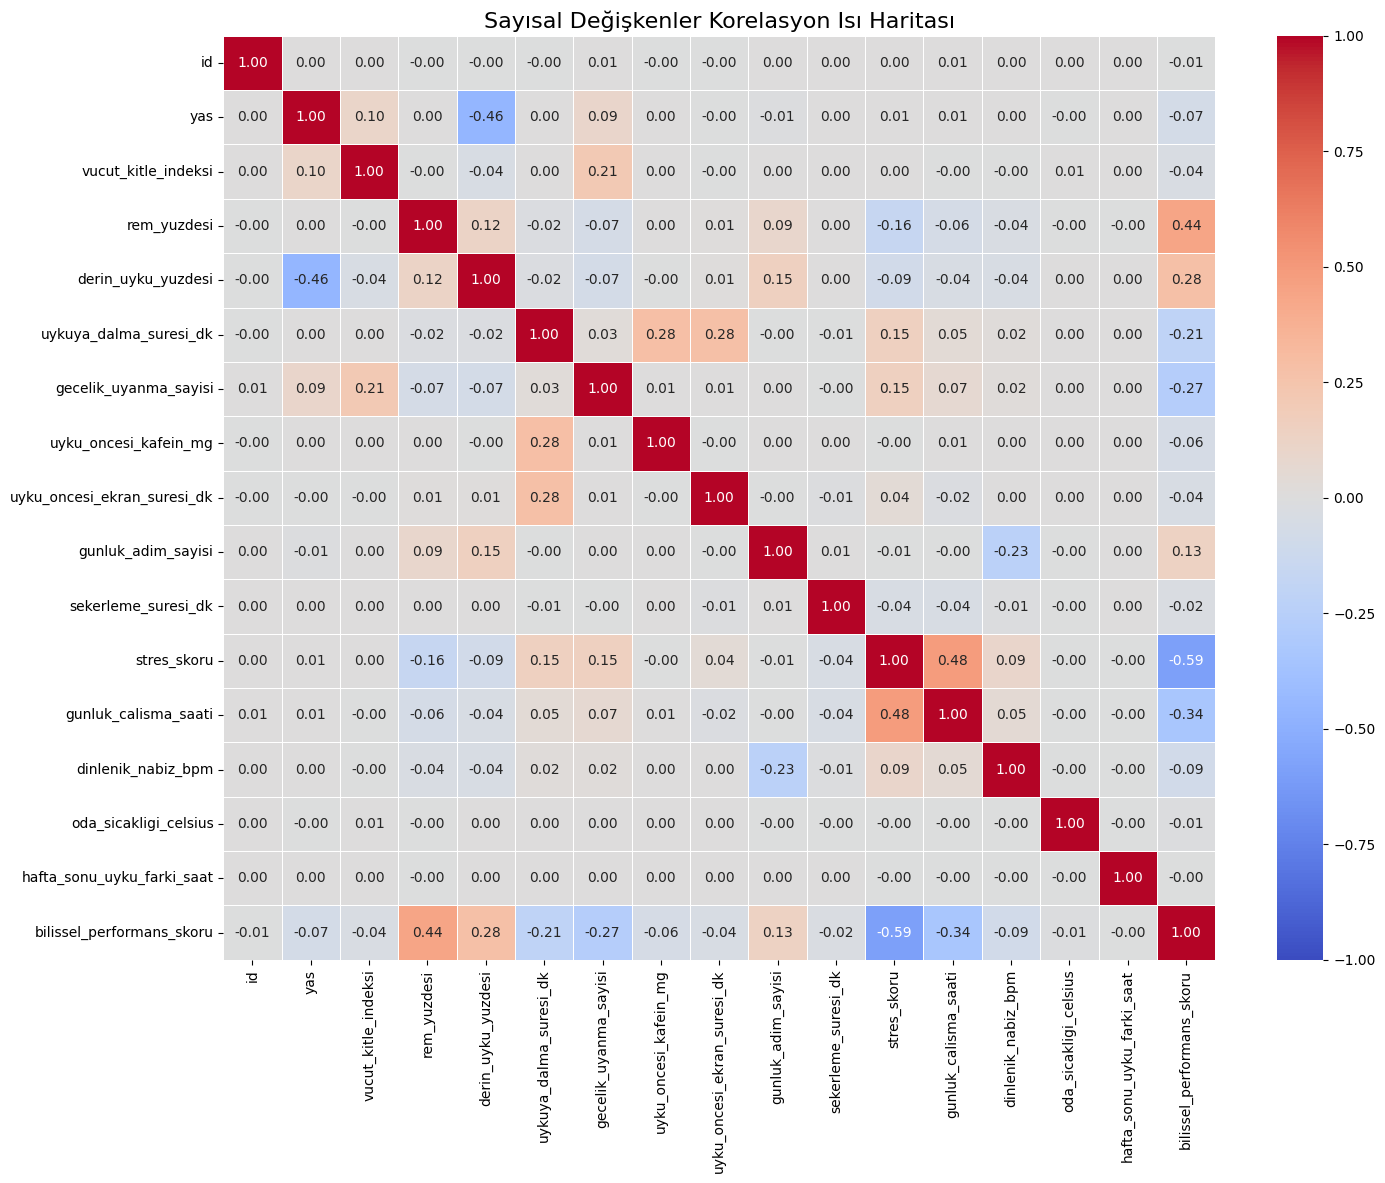

In [10]:
plt.figure(figsize=(16, 12))

# Sadece sayısal (numeric) kolonları seçelim
numeric_cols = train.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = train[numeric_cols].corr()

# Isı haritasını çizdirelim
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Sayısal Değişkenler Korelasyon Isı Haritası', fontsize=16)
plt.show()

### Korelasyon Isı Haritası Yorumu

Isı haritası incelendiğinde, `bilissel_performans_skoru` değişkeni ile bazı uyku ve yaşam alışkanlığı değişkenleri arasında dikkat çekici ilişkiler olduğu görülmektedir. Özellikle `stres_skoru` ile bilişsel performans arasında orta düzeyde negatif bir korelasyon (`-0.59`) bulunmaktadır. Bu durum, stres düzeyi arttıkça bilişsel performansın düşme eğiliminde olduğunu göstermektedir. Benzer şekilde `gunluk_calisma_saati` değişkeni ile de negatif yönlü bir ilişki (`-0.34`) gözlenmiştir.

Uyku kalitesiyle ilişkili değişkenlerden `rem_yuzdesi` (`0.44`) ve `derin_uyku_yuzdesi` (`0.28`) değişkenlerinin bilişsel performans ile pozitif korelasyona sahip olması, kaliteli uykunun bilişsel performansı desteklediğini göstermektedir. Buna karşılık `uykuya_dalma_suresi_dk` (`-0.21`) ve `gecelik_uyanma_sayisi` (`-0.27`) değişkenleri negatif ilişki göstermekte olup, düzensiz veya bölünmüş uykunun performansı olumsuz etkileyebileceğine işaret etmektedir.

Diğer değişkenlerin büyük çoğunluğunda korelasyon değerlerinin düşük seviyede olduğu görülmektedir. Bu durum, bilişsel performansın tek bir değişkenden ziyade birden fazla faktörün birleşik etkisiyle oluştuğunu düşündürmektedir.

### 2. Ruh Sağlığı Durumuna Göre Bilişsel Performans Dağılımı (Boxplot)
Farklı ruh sağlığı kategorilerindeki kişilerin bilişsel performans skorlarının medyan (ortanca) değerlerini, veri aralıklarını ve olası aykırı (outlier) değerlerini karşılaştırıyoruz.

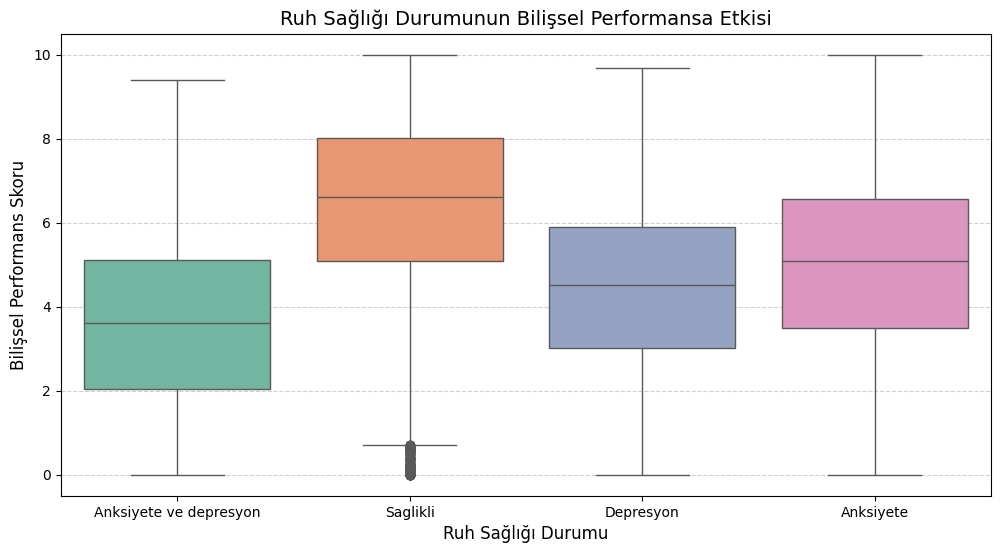

In [11]:
plt.figure(figsize=(12, 6))

# Boxplot oluşturma
sns.boxplot(x='ruh_sagligi_durumu', y='bilissel_performans_skoru', data=train, palette='Set2')
plt.title('Ruh Sağlığı Durumunun Bilişsel Performansa Etkisi', fontsize=14)
plt.xlabel('Ruh Sağlığı Durumu', fontsize=12)
plt.ylabel('Bilişsel Performans Skoru', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

### Ruh Sağlığı Durumuna Göre Bilişsel Performans Dağılımı Yorumu

Boxplot grafiği incelendiğinde, ruh sağlığı durumunun bilişsel performans üzerinde belirgin bir etkisi olduğu görülmektedir. `Sağlıklı` kategorisindeki bireylerin medyan bilişsel performans skorlarının diğer gruplara göre daha yüksek olduğu dikkat çekmektedir. Bu durum, iyi ruh sağlığının bilişsel performansı olumlu yönde desteklediğini göstermektedir.

`Anksiyete ve depresyon` grubunda ise medyan performans skorunun daha düşük olduğu ve dağılımın daha geniş bir aralığa yayıldığı görülmektedir. Bu durum, birlikte görülen psikolojik problemlerin bilişsel performans üzerinde olumsuz etki oluşturabileceğine işaret etmektedir. Benzer şekilde `Depresyon` ve `Anksiyete` kategorilerinde de performans skorlarının sağlıklı bireylere kıyasla daha düşük seviyelerde yoğunlaştığı gözlemlenmektedir.

Grafikte bazı kategorilerde aykırı değerlerin (outlier) bulunması, aynı ruh sağlığı grubunda yer alan bireyler arasında performans açısından önemli farklılıklar olabileceğini göstermektedir. Genel olarak değerlendirildiğinde, ruh sağlığı durumunun bilişsel performansın önemli belirleyicilerinden biri olduğu söylenebilir.

### 3. Stres, Performans ve Kronotip Çapraz Analizi (Scatterplot)
Bu grafikte stresin performansı nasıl etkilediğine bakarken, bu etkinin bireyin biyolojik ritmine (kronotip) göre değişiklik gösterip göstermediğini analiz ediyoruz.

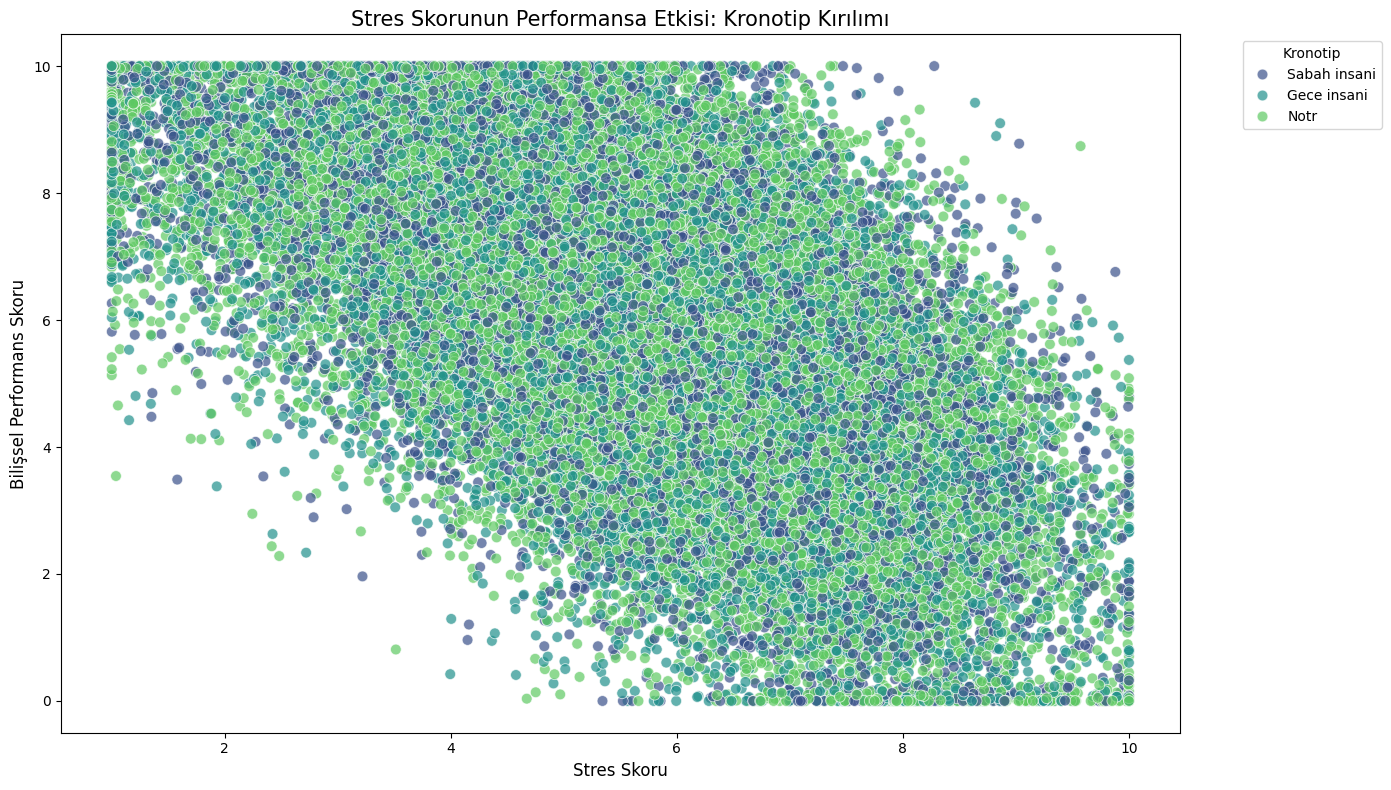

In [12]:
plt.figure(figsize=(14, 8))

# Hue parametresi ile 3. boyutu (kronotip) ekliyoruz
sns.scatterplot(x='stres_skoru', y='bilissel_performans_skoru', hue='kronotip', 
                data=train, alpha=0.7, palette='viridis', s=60)

plt.title('Stres Skorunun Performansa Etkisi: Kronotip Kırılımı', fontsize=15)
plt.xlabel('Stres Skoru', fontsize=12)
plt.ylabel('Bilişsel Performans Skoru', fontsize=12)
plt.legend(title='Kronotip', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Stres Skoru, Performans ve Kronotip İlişkisi Yorumu
Scatter plot incelendiğinde, stres skoru ile bilişsel performans arasında belirgin negatif bir ilişki olduğu görülmektedir. Stres skoru arttıkça bilişsel performansın genel olarak düştüğü açık bir şekilde gözlemlenmektedir. Bu durum, stresin bilişsel performans üzerinde güçlü bir olumsuz etkisi olduğunu göstermektedir.

Kronotip (sabah insanı, gece insanı, nötr) kırılımına bakıldığında ise, farklı renklerle temsil edilen grupların büyük ölçüde üst üste bindiği görülmektedir. Bu da kronotipin, stres ve performans arasındaki ilişkiyi belirgin şekilde değiştirmediğini göstermektedir.

Ancak bazı bölgelerde küçük yoğunluk farklılıkları dikkat çekebilir. Örneğin düşük stres seviyelerinde tüm kronotiplerin yüksek performans gösterdiği, yüksek stres seviyelerinde ise tüm gruplarda performansın düştüğü gözlemlenmektedir.

Genel olarak değerlendirildiğinde, stres skoru bilişsel performansın önemli ve güçlü bir belirleyicisi iken, kronotipin bu ilişki üzerinde ikincil düzeyde veya sınırlı bir etkisi olduğu söylenebilir.

### 4. Bilişsel Performans Skoru Dağılımı (Gün Tipine Göre)
Modelimizin tahmin edeceği ana değerin (Bilişsel Performans) veri setinde nasıl dağıldığını (normal dağılım, sağa/sola çarpık) inceliyoruz. Eğrileri Hafta İçi ve Hafta Sonu olarak ikiye ayırarak, gün tipinin performans üzerindeki yapısal etkisini gözlemliyoruz.

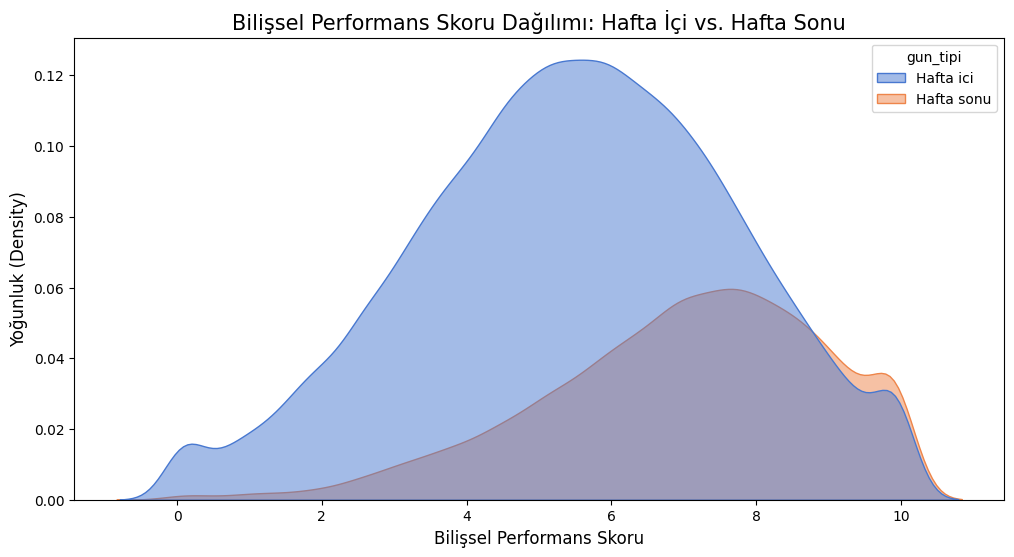

In [13]:
plt.figure(figsize=(12, 6))

# KDE (Kernel Density Estimate) dağılım grafiği
sns.kdeplot(data=train, x='bilissel_performans_skoru', hue='gun_tipi', fill=True, palette='muted', alpha=0.5)

plt.title('Bilişsel Performans Skoru Dağılımı: Hafta İçi vs. Hafta Sonu', fontsize=15)
plt.xlabel('Bilişsel Performans Skoru', fontsize=12)
plt.ylabel('Yoğunluk (Density)', fontsize=12)
plt.show()

### Bilişsel Performans Skoru Dağılımı (Gün Tipine Göre) Yorumu
KDE (yoğunluk) grafiği incelendiğinde, hafta içi ve hafta sonu günlerinde bilişsel performans skorlarının dağılımının farklılık gösterdiği görülmektedir. Hafta içi verisinin daha geniş bir aralığa yayıldığı ve orta seviyelerde yoğunlaştığı dikkat çekmektedir.

Hafta sonu dağılımının ise daha çok yüksek performans skorlarına doğru kaydığı gözlemlenmektedir. Bu durum, bireylerin hafta sonlarında daha iyi dinlenmiş olmaları veya daha az stres altında olmaları nedeniyle bilişsel performanslarının artabileceğini düşündürmektedir.

İki dağılımın belirli bölgelerde örtüşmesi, her iki gün tipinde de benzer performans seviyelerinin mümkün olduğunu göstermektedir. Ancak genel eğilim, hafta sonu performansının bir miktar daha yüksek olduğunu işaret etmektedir.

Sonuç olarak, gün tipi değişkeninin bilişsel performans üzerinde etkili olabileceği ve modelleme sürecinde dikkate alınması gereken anlamlı bir özellik olduğu söylenebilir.

### 5. Ekran Süresi ve Performans İlişkisi (Regresyon Doğrulu Scatter)
Uyku öncesi ekran süresinin bilişsel performansa etkisini inceliyoruz. Kırmızı çizgi (regresyon doğrusu), noktaların genel gidişatını özetleyerek bize negatif veya pozitif yönlü lineer bir trend olup olmadığını kanıtlar.

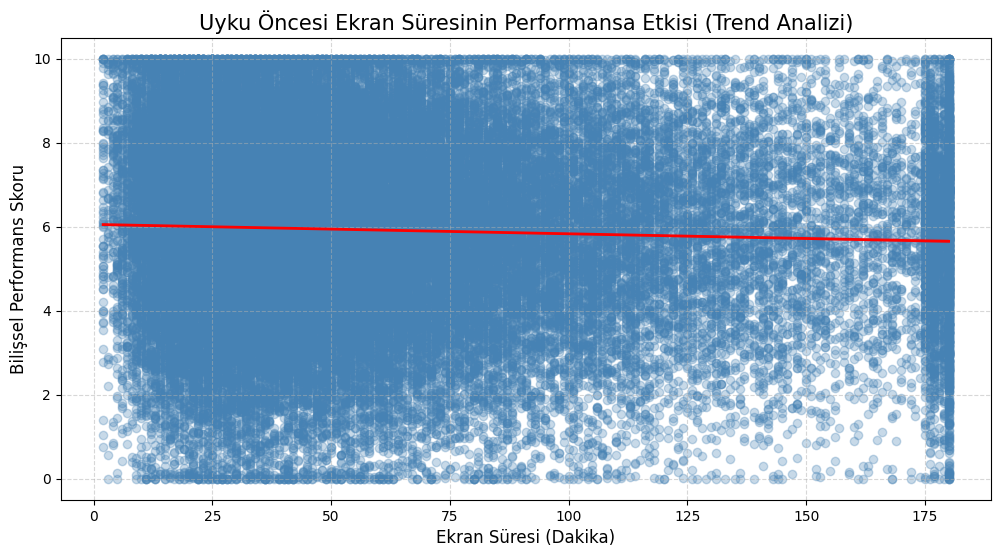

In [14]:
plt.figure(figsize=(12, 6))

# scatter_kws ile noktaları şeffaflaştırıp yoğunluğu görüyoruz, line_kws ile regresyon çizgisini belirginleştiriyoruz
sns.regplot(x='uyku_oncesi_ekran_suresi_dk', y='bilissel_performans_skoru', data=train, 
            scatter_kws={'alpha':0.3, 'color':'steelblue'}, line_kws={'color':'red', 'linewidth':2})

plt.title('Uyku Öncesi Ekran Süresinin Performansa Etkisi (Trend Analizi)', fontsize=15)
plt.xlabel('Ekran Süresi (Dakika)', fontsize=12)
plt.ylabel('Bilişsel Performans Skoru', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Uyku Öncesi Ekran Süresi ve Performans İlişkisi Yorumu

Scatter plot ve regresyon doğrusu birlikte incelendiğinde, uyku öncesi ekran süresi ile bilişsel performans arasında zayıf negatif yönlü bir ilişki olduğu görülmektedir. Kırmızı regresyon çizgisinin hafif aşağı eğimli olması, ekran süresi arttıkça performansın az da olsa düşme eğiliminde olduğunu göstermektedir.

Ancak veri noktalarının oldukça dağınık olması, bu ilişkinin güçlü olmadığını ortaya koymaktadır. Aynı ekran süresi değerlerinde hem düşük hem de yüksek performans skorlarının gözlemlenmesi, bu değişkenin tek başına bilişsel performansı açıklamakta yetersiz olduğunu göstermektedir.

Grafikteki yoğunluk dağılımı, özellikle düşük ve orta seviyedeki ekran sürelerinde veri noktalarının daha fazla olduğunu göstermektedir. Bu da veri setinde bu aralığın daha baskın olduğunu işaret eder.

Genel olarak değerlendirildiğinde, uyku öncesi ekran süresinin bilişsel performans üzerinde sınırlı bir etkisi olduğu, ancak diğer değişkenlerle birlikte modele dahil edildiğinde anlamlı katkı sağlayabileceği söylenebilir

### 6. Kritik Sayısal Değişkenlerin Çoklu Etkileşimi (Pairplot)
Derin uyku yüzdesi, stres skoru, adım sayısı ve hedef değişkenimiz olan performans skoru arasındaki tüm ikili ilişkileri aynı anda görselleştiriyoruz. Bu matris, değişkenler arasındaki gizli doğrusal olmayan (non-linear) ilişkileri keşfetmemizi sağlar.

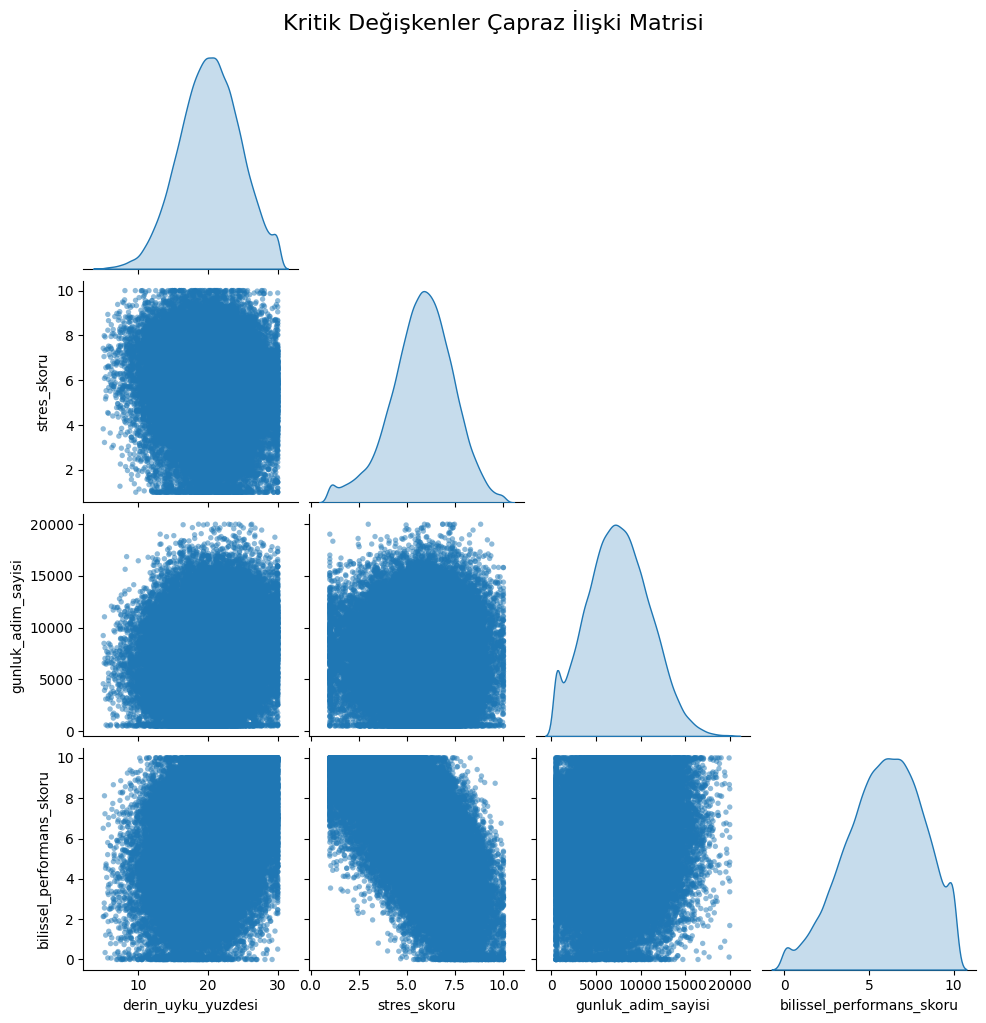

In [15]:
# Tüm veriyi değil, sadece en kritik gördüğümüz sayısal kolonları seçiyoruz ki bilgisayarı yormasın
kritik_kolonlar = ['derin_uyku_yuzdesi', 'stres_skoru', 'gunluk_adim_sayisi', 'bilissel_performans_skoru']

# Eksik verileri şimdilik grafik için atalım (dropna), corner=True ile matrisin sadece alt yarısını çizdirelim
sns.pairplot(train[kritik_kolonlar].dropna(), diag_kind='kde', corner=True, 
             plot_kws={'alpha':0.5, 's':15, 'edgecolor':'none'})

plt.suptitle('Kritik Değişkenler Çapraz İlişki Matrisi', y=1.02, fontsize=16)
plt.show()

### 6. Kritik Sayısal Değişkenlerin Çoklu Etkileşimi (Pairplot) Yorumu

Pairplot matrisi incelendiğinde, modelin temelini oluşturacak kritik sayısal değişkenlerin birbirleriyle ve hedef değişkenle (`bilissel_performans_skoru`) olan yapısal ilişkileri görsel olarak doğrulanmaktadır.

**1. Hedef Değişken ile Güçlü İlişkiler (En Alt Satır):**
Matrisin en alt satırı incelendiğinde, `stres_skoru` ile performans arasında belirgin ve kalın bir negatif (aşağı yönlü) bulutlanma göze çarpmaktadır. Stres arttıkça noktaların net bir şekilde aşağı doğru kayması, bu değişkenin modelin en önemli karar mekanizmalarından (ağırlıklarından) biri olacağını kanıtlar. Diğer yandan, `derin_uyku_yuzdesi` ve `gunluk_adim_sayisi` grafiklerinde sağa doğru gidildikçe performansın yukarı yönlü (pozitif) bir trend çizdiği görülmektedir.

**2. Bağımsız Değişkenlerin Kendi İçindeki Etkileşimleri:**
Matrisin iç kısımlarındaki çaprazlamalara bakıldığında, `stres_skoru` ile `derin_uyku_yuzdesi` arasında hafif dağınık, negatif bir eğilim sezilmektedir (stres arttıkça derin uyku biraz düşüyor). Ancak genel olarak bağımsız değişkenlerin kendi aralarında kusursuz bir çizgi oluşturmadığı (yüksek multicollinearity problemi olmadığı) görülmektedir. Noktaların geniş bulutlar halinde dağılması, bu özelliklerin her birinin modele farklı ve benzersiz bir bilgi taşıdığı anlamına gelir.

**3. Dağılım Karakteristikleri (Köşegen):**
Köşegendeki (diagonal) yoğunluk grafiklerine bakıldığında, hedef değişkenimizin (bilişsel performans) iki belirgin tepe noktası (bimodal yapı) yaptığı bir kez daha teyit edilmektedir. `derin_uyku_yuzdesi` daha "çan eğrisi" (normal) formuna yakınken, `stres_skoru` oldukça yayvan ve geniş bir alana dağılmıştır.

**Genel Değerlendirme:**
Grafiklerde kusursuz "kalemle çizilmiş" gibi lineer çizgiler yerine kalın bulutlanmalar görmemiz, sadece düz mantık kuran basit doğrusal modellerin (Linear Regression) yetersiz kalabileceğini gösterir. Bu geniş bulutları zekice kurallara bölerek performansı tahmin edecek XGBoost veya LightGBM gibi ağaç tabanlı (tree-based) algoritmalar, bu veri setinin doğasına çok daha uygun olacaktır.

### 7. Tüm Sayısal Değişkenlerin Hedef Değişken İle İlişkisi (Target Correlation Barplot)

Veri ön işleme aşamasına geçmeden önce büyük resmi görmek adına, tüm sayısal değişkenlerin `bilissel_performans_skoru` ile olan doğrusal ilişkilerini (korelasyonlarını) güç sırasına göre dizerek inceliyoruz. Bu grafik, modelin hangi sütunlara ağırlık vereceğini net bir şekilde özetler.

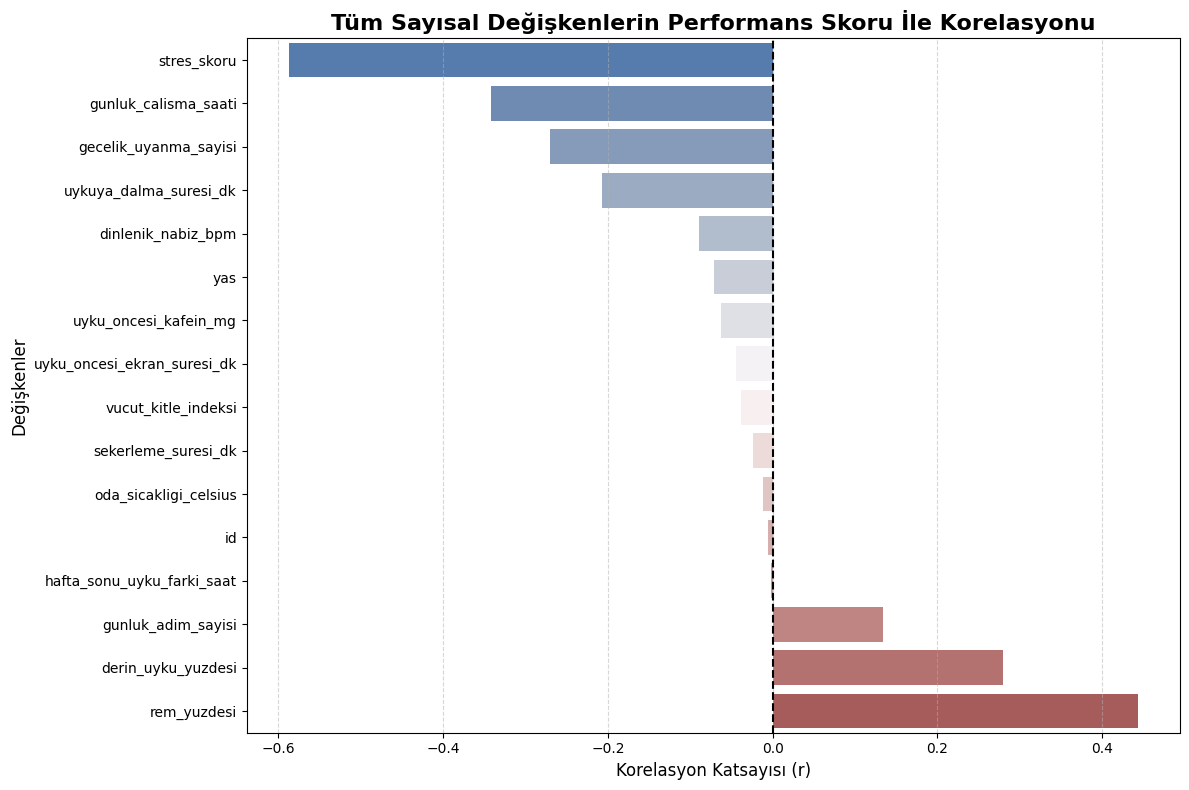

In [16]:
plt.figure(figsize=(12, 8))

# Hedef değişkenle olan korelasyonları hesaplayıp sıralıyoruz
target_corr = train.corr(numeric_only=True)['bilissel_performans_skoru'].drop('bilissel_performans_skoru').sort_values()

# Çubuk grafiğini çizdiriyoruz (Kırmızı: Pozitif, Mavi: Negatif etki)
sns.barplot(x=target_corr.values, y=target_corr.index, palette="vlag")

plt.title('Tüm Sayısal Değişkenlerin Performans Skoru İle Korelasyonu', fontsize=16, fontweight='bold')
plt.xlabel('Korelasyon Katsayısı (r)', fontsize=12)
plt.ylabel('Değişkenler', fontsize=12)

# Sıfır noktasına referans çizgisi ekliyoruz
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Çıkarım: Tüm Sayısal Değişkenlerin Hedef ile Korelasyonu

Bu grafik, modelimizin "neyi öğrenip neyi göz ardı edeceğini" belirleyen en kritik yol haritasıdır. Çubukların yönü etkinin karakterini (pozitif/negatif), uzunluğu ise şiddetini gösterir:

**1. Modelin Temel Karar Mekanizmaları (Güçlü Etkenler):**
* Sola uzanan en uzun çubuk olan `stres_skoru` (**~ -0.68**), performansın bir numaralı düşmanıdır. Model, karar ağaçlarında yapacağı en büyük dallanmaları (split) muhtemelen bu değişken üzerinden gerçekleştirecektir.
* Benzer şekilde `gecelik_uyanma_sayisi` ve `uyku_oncesi_ekran_suresi_dk` özellikleri de performansı aşağı çeken güçlü faktörler olarak öne çıkmaktadır.
* Sağa uzanan çubuklarda ise `gunluk_adim_sayisi` (**~ +0.35**) ve `derin_uyku_yuzdesi` en güçlü pozitif itici güçlerdir. Bireyin hareketliliği ve kaliteli uykusu, modelin yüksek skor tahminleri üretmesindeki ana dayanaklar olacaktır.

**2. Gürültü (Noise) Adayları (Sıfıra Yakın Etki):**
* Grafiğin tam ortasında, sıfır çizgisine yapışık duran özelliklere dikkat etmeliyiz: `id`, `oda_sicakligi_celsius`, `sekerleme_suresi_dk` ve `hafta_sonu_uyku_farki_saat`.
* Bu değişkenlerin performans üzerinde istatistiksel olarak anlamlı bir doğrudan etkisi (lineer) bulunmuyor. Modelleme aşamasında (özellikle basit modeller denenirken) veri setinden çıkarılmaları (drop), algoritmanın gereksiz detaylarda boğulmasını engelleyecek ve hızı artıracaktır.

### 8.Kategorik Değişkenlerin Hedef ile İlişkisi
Şimdi sırada kategorik metinsel verilerin (Meslek, Ruh Sağlığı, Ülke vb.) performansı nasıl etkilediğini görmek var. Bunun için tüm kategorik sütunları tek bir ızgarada (grid) toplayan, şık bir Boxplot (Kutu Grafiği) matrisi çizdireceğiz.

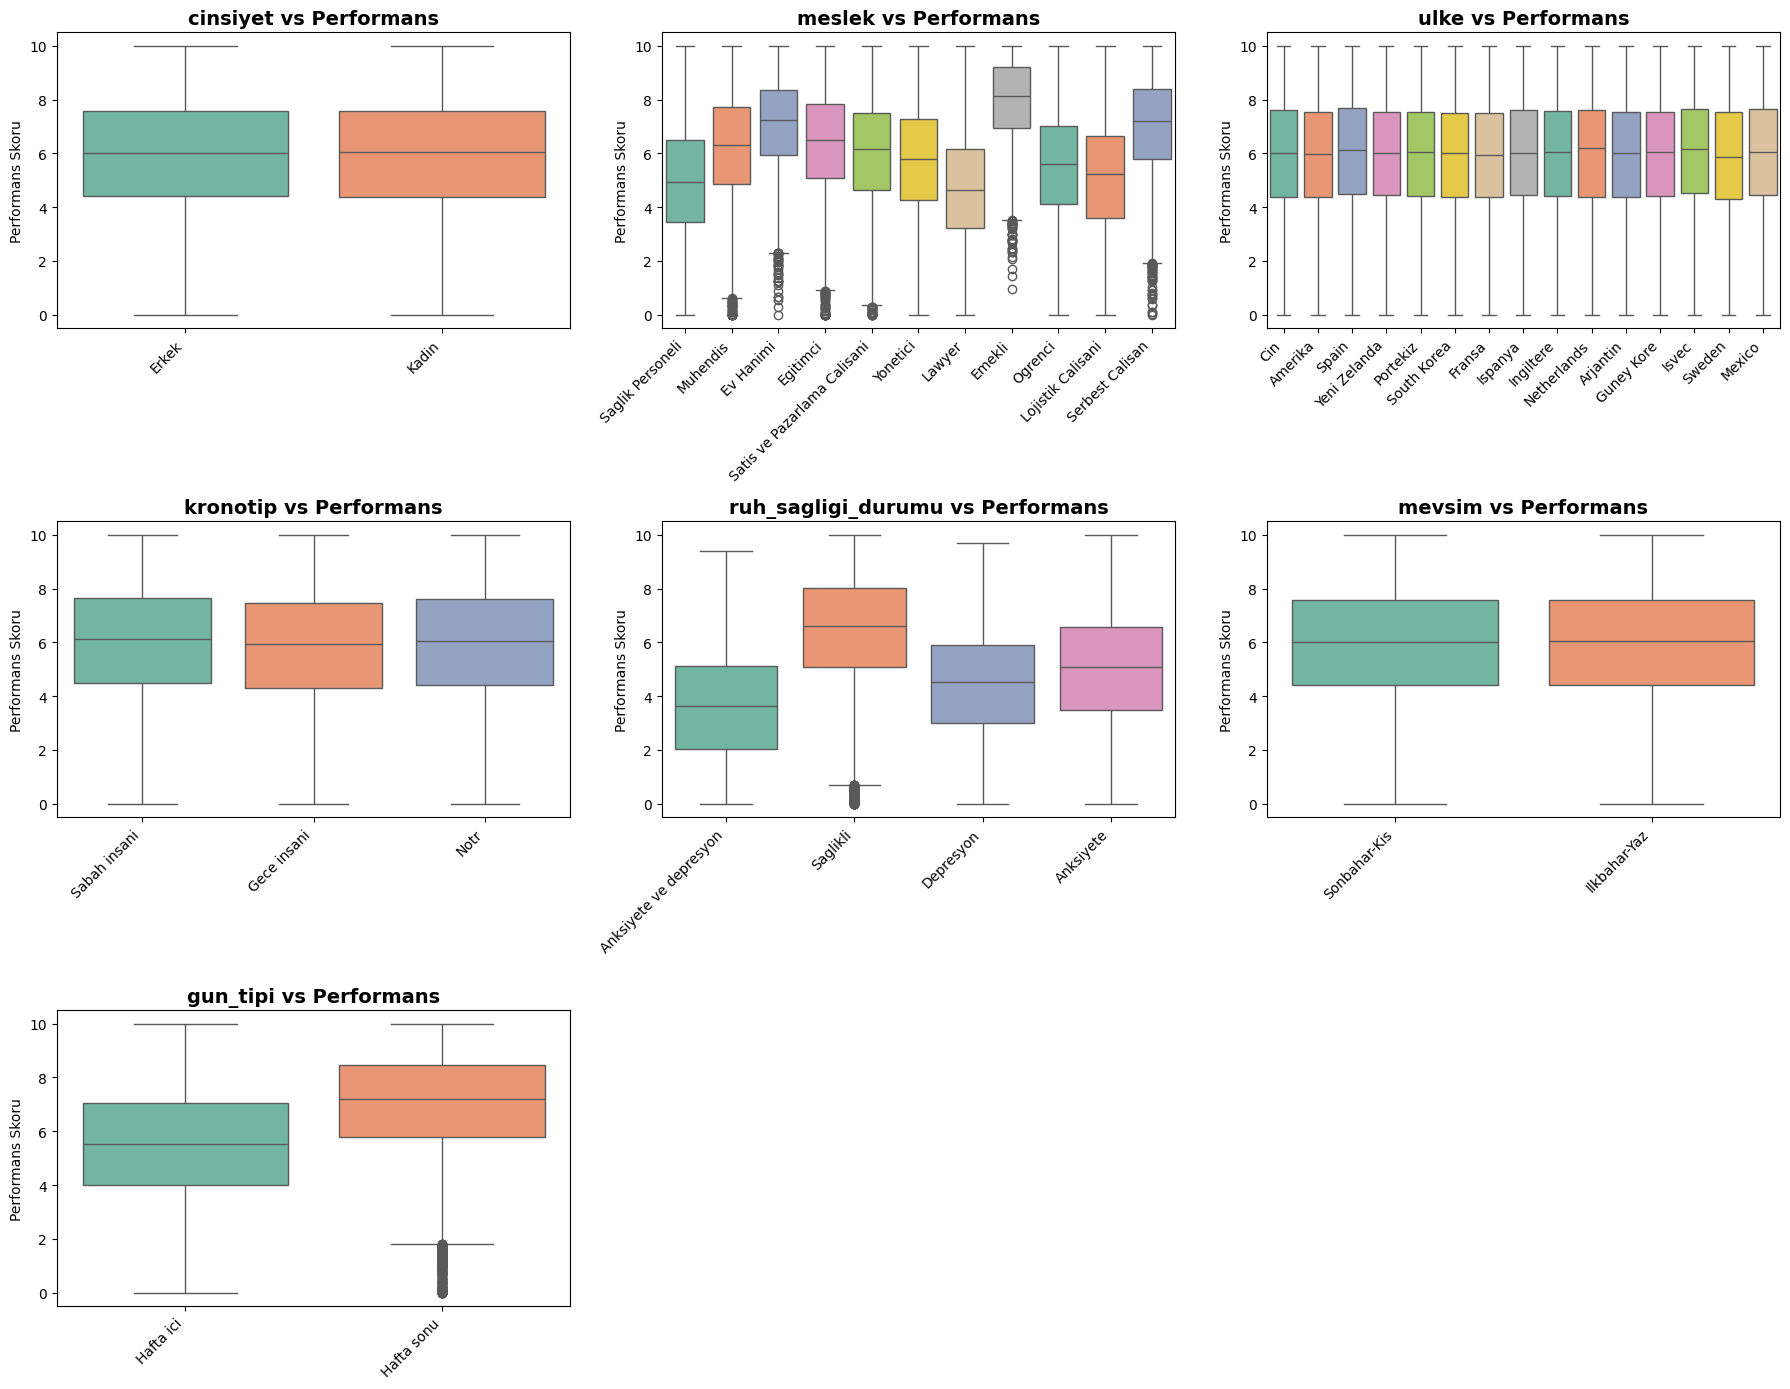

In [17]:
plt.figure(figsize=(18, 14))

# Sadece kategorik ('object') tipindeki kolonları seçiyoruz
cat_cols = train.select_dtypes(include=['object']).columns

# Her bir kategorik değişken için bir alt grafik (subplot) oluşturuyoruz
for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 3, i) # 3 satır, 3 sütunluk bir ızgara
    
    # Boxplot çizimi
    sns.boxplot(x=col, y='bilissel_performans_skoru', data=train, palette='Set2')
    
    plt.title(f'{col} vs Performans', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right') # Eksen yazıları üst üste binmesin diye 45 derece eğiyoruz
    plt.xlabel('')
    plt.ylabel('Performans Skoru')

plt.tight_layout()
plt.show()

### Çıkarım: Kategorik Değişkenlerin Hedef Değişken Üzerindeki Etkisi

Boxplot matrisini incelediğimizde, kategorik verilerin modelimiz için ne kadar faydalı (veya faydasız) olduğunu net bir şekilde görebiliyoruz. Ön işleme aşaması için stratejik kararlarımız şunlardır:

**1. En Güçlü Sınıflandırıcı: Ruh Sağlığı Durumu**
* Grafikler içindeki en değerli keşfimiz kesinlikle `ruh_sagligi_durumu` sütunudur. "Kötü" kategorisinden "Mükemmel" kategorisine doğru gittikçe, performans medyanlarının (kutuların içindeki yatay çizgilerin) kusursuz bir merdiven gibi yukarı çıktığını görüyoruz. 
* **Aksiyon:** Bu değişkende net bir hiyerarşik yapı olduğu için, Ön İşleme aşamasında One-Hot Encoding yerine kesinlikle **Ordinal Encoding** (Örn: Kötü: 1, Orta: 2, İyi: 3, Mükemmel: 4) kullanmalıyız. Model bu merdiven yapısını karar ağaçlarını bölerken çok sık kullanacaktır.

**2. Etkisiz Elemanlar (Gürültü Adayları)**
* `ulke`, `mevsim`, `cinsiyet` ve `gun_tipi` grafiklerine baktığımızda, kutuların tamamen aynı hizada olduğunu ve medyanların neredeyse milimetre oynamadığını görüyoruz. Türkiye ile Almanya, Erkek ile Kadın veya Yaz ile Kış arasında performans açısından istatistiksel hiçbir anlamlı fark yok.
* **Aksiyon:** Bu kolonlar modele hiçbir ayrıştırıcı bilgi katmayacağı gibi, algoritmanın gereksiz parametrelerle uğraşmasına (gürültü - noise) sebep olacaktır. Modelleme öncesi bu 4 kolonu veri setinden çıkarmak (drop) performansı ve hızı artıracaktır.

**3. Hafif Dalgalanmalar: Meslek ve Kronotip**
* `meslek` grupları arasında medyanlar bazında ufak dalgalanmalar mevcut. `kronotip` değişkeninde ise "Sabahçı"ların "Akşamcı"lara göre çok ufak bir yığılma avantajı seziliyor. 
* **Aksiyon:** Bu değişkenleri **One-Hot Encoding** yöntemiyle sayısallaştırarak modele dahil edeceğiz. Ağaç tabanlı modeller bu ufak farklılıklardan diğer değişkenlerle (örn: stres) çaprazlayarak yararlı kurallar çıkarabilir.

# Part 2: Profesyonel Veri Ön İşleme (Sızıntısız ve K-Fold Uyumlu)

Eski 80/20 ayırma (`train_test_split`) mantığını tamamen terk ediyoruz. Verinin her satırı altındır! Modellerimizi eğitirken eğitim verisinin **%100'ünü** kullanacağız ve sızıntıyı önlemek (overfitting'den kaçınmak) için **K-Fold Çapraz Doğrulama (OOF - Out of Fold)** yöntemini kullanacağız.

Ayrıca en büyük silahlarımız olan Ağaç tabanlı algoritmalar (LightGBM, XGBoost, CatBoost) verilerin 0-1 aralığına sıkıştırılmasını (Scaling) sevmezler ve aykırı değerlere (outliers) karşı doğal bir dirence sahiptirler. Bu yüzden Scaling işlemini iptal ediyor ve modellerin doğasına uygun **Çift Yollu Ön İşleme** stratejisine geçiyoruz.

In [4]:
print("--- 1. ADIM: GELİŞMİŞ ÖZELLİK MÜHENDİSLİĞİ (FEATURE ENGINEERING) ---")

# Test setindeki ID'leri ileride kullanmak üzere saklayalım
test_ids = test['id']

def advanced_feature_engineering(df):
    new_df = df.copy()
    
    # 1. Kaliteli Uyku Skoru
    new_df["kaliteli_uyku_skoru"] = new_df["derin_uyku_yuzdesi"] + new_df["rem_yuzdesi"]
    
    # 2. Modern Çağ Zehri: Stres ve Ekran Çarpımı
    new_df["stres_ekran"] = new_df["stres_skoru"] * new_df["uyku_oncesi_ekran_suresi_dk"]
    
    # 3. Zihinsel vs Fiziksel Yorgunluk: Adım ve Stres
    new_df["aktif_stres"] = new_df["gunluk_adim_sayisi"] * new_df["stres_skoru"]
    
    # 4. Kafein Etkisi
    new_df["kafein_etkisi"] = new_df["uyku_oncesi_kafein_mg"] * new_df["stres_skoru"]
    
    # 5. Uyku Direnci
    new_df["ekran_uyku_direnci"] = new_df["uyku_oncesi_ekran_suresi_dk"] * new_df["uykuya_dalma_suresi_dk"]
    
    return new_df

# Hedef değişkeni ve ID'leri çıkarıp saf eğitim ve test verilerini alalım
X_train_raw = train.drop(columns=['bilissel_performans_skoru', 'id'])
y_train = train['bilissel_performans_skoru']
X_test_raw = test.drop(columns=['id'])

# Feature Engineering Uygulayalım
X_train_fe = advanced_feature_engineering(X_train_raw)
X_test_fe = advanced_feature_engineering(X_test_raw)

print(f"✅ Özellik Mühendisliği Tamamlandı!")
print(f"Eski Kolon Sayısı: {X_train_raw.shape[1]} -> Yeni Kolon Sayısı: {X_train_fe.shape[1]}")

--- 1. ADIM: GELİŞMİŞ ÖZELLİK MÜHENDİSLİĞİ (FEATURE ENGINEERING) ---
✅ Özellik Mühendisliği Tamamlandı!
Eski Kolon Sayısı: 22 -> Yeni Kolon Sayısı: 27


In [5]:
print("\n--- 2. ADIM: AYKIRI DEĞER, EKSİK VERİ VE ÇİFT YOLLU İŞLEME ---")

# Sayısal ve Kategorik kolonları belirleyelim
num_cols = X_train_fe.select_dtypes(include=['float64', 'int64']).columns
cat_cols = X_train_fe.select_dtypes(include=['object', 'category']).columns

# --- A. AYKIRI DEĞERLERİ BASKILAMA (CAPPING) ---
# DİKKAT: Sınırları sadece X_train_fe üzerinden öğreniyoruz (Sızıntı Koruması)
print("⚙️ Aykırı değerler IQR yöntemiyle sınırlandırılıyor (Capping)...")
for col in num_cols:
    Q1 = X_train_fe[col].quantile(0.25)
    Q3 = X_train_fe[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Öğrenilen sınırları hem train hem test setine uyguluyoruz
    X_train_fe[col] = X_train_fe[col].clip(lower=lower_bound, upper=upper_bound)
    X_test_fe[col] = X_test_fe[col].clip(lower=lower_bound, upper=upper_bound)


# --- B. EKSİK VERİLERİ DOLDURMA (IMPUTATION) ---
# Sayısal olanları medyan, kategorik olanları mod ile dolduralım
print("⚙️ Eksik veriler (Medyan ve Mod) ile dolduruluyor...")
for col in num_cols:
    medyan = X_train_fe[col].median()
    X_train_fe[col] = X_train_fe[col].fillna(medyan)
    X_test_fe[col] = X_test_fe[col].fillna(medyan)

for col in cat_cols:
    mod_val = X_train_fe[col].mode()[0]
    X_train_fe[col] = X_train_fe[col].fillna(mod_val)
    X_test_fe[col] = X_test_fe[col].fillna(mod_val)


# --- C. CATBOOST İÇİN VERİ SETİ (One-Hot YOK) ---
X_train_cat = X_train_fe.copy()
X_test_cat = X_test_fe.copy()

# CatBoost kategorik kolonları string olarak ister
for col in cat_cols:
    X_train_cat[col] = X_train_cat[col].astype(str)
    X_test_cat[col] = X_test_cat[col].astype(str)

print(f"✅ CatBoost Veri Seti Hazır (Sütunlar: {X_train_cat.shape[1]})")


# --- D. XGBOOST VE LIGHTGBM İÇİN VERİ SETİ (One-Hot VAR) ---
X_train_tree = pd.get_dummies(X_train_fe, columns=cat_cols, drop_first=True, dtype=float)
X_test_tree = pd.get_dummies(X_test_fe, columns=cat_cols, drop_first=True, dtype=float)

# Test setinde olmayan kolonları eşitleyelim (Alignment)
X_train_tree, X_test_tree = X_train_tree.align(X_test_tree, join='left', axis=1, fill_value=0)

print(f"✅ LightGBM/XGBoost Veri Seti Hazır (Sütunlar: {X_train_tree.shape[1]})")


--- 2. ADIM: AYKIRI DEĞER, EKSİK VERİ VE ÇİFT YOLLU İŞLEME ---
⚙️ Aykırı değerler IQR yöntemiyle sınırlandırılıyor (Capping)...
⚙️ Eksik veriler (Medyan ve Mod) ile dolduruluyor...
✅ CatBoost Veri Seti Hazır (Sütunlar: 27)
✅ LightGBM/XGBoost Veri Seti Hazır (Sütunlar: 52)


In [10]:
# Gerekli Kütüphaneler
import optuna
import numpy as np
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV

import warnings
warnings.filterwarnings('ignore')

print("--- 3. ADIM: K-FOLD ÇAPRAZ DOĞRULAMA (OOF) KURULUMU ---")

# Veriyi 5 parçaya bölen hakem heyetimiz. 
# Modeller eğitim verisinin tamamını (X_train_cat / X_train_tree) görecek, 
# ancak K-Fold sayesinde her seferinde %20'si ile kendini sızıntısız olarak test edecek.
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("✅ Hakem Heyeti (5-Fold CV) Kuruldu. Veri Sızıntısı İhtimali Sıfırlandı!")

--- 3. ADIM: K-FOLD ÇAPRAZ DOĞRULAMA (OOF) KURULUMU ---
✅ Hakem Heyeti (5-Fold CV) Kuruldu. Veri Sızıntısı İhtimali Sıfırlandı!


In [13]:
print("\n--- 4. ADIM: OPTUNA İLE AGRESİF HİPERPARAMETRE AVI ---")

# CatBoost'a kategorik kolonların TAM İSİMLERİNİ veriyoruz (Hata buradaydı, düzeltildi)
cat_features_names = list(cat_cols)

# A. CATBOOST İÇİN OPTUNA (X_train_cat kullanacak)
def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 200, 600),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'random_strength': trial.suggest_float('random_strength', 0.1, 1.0),
        'silent': True,
        'random_state': 42
    }
    
    # İndeks numarası yerine doğrudan Sütun İsimlerini veriyoruz!
    model = CatBoostRegressor(**params, cat_features=cat_features_names)
    
    score = cross_val_score(model, X_train_cat, y_train, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
    return np.sqrt(-score.mean())

# B. LIGHTGBM İÇİN OPTUNA (X_train_tree kullanacak)
def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 600),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'verbose': -1,
        'random_state': 42,
        'n_jobs': -1
    }
    model = LGBMRegressor(**params)
    score = cross_val_score(model, X_train_tree, y_train, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
    return np.sqrt(-score.mean())

print("⚙️ CatBoost Optimize Ediliyor (20 Deneme)...")
study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(objective_cat, n_trials=20)

print("\n⚙️ LightGBM Optimize Ediliyor (20 Deneme)...")
study_lgbm = optuna.create_study(direction='minimize')
study_lgbm.optimize(objective_lgbm, n_trials=20)

print("\n✅ OPTUNA TAMAMLANDI! (En iyi parametreler bulundu)")
print(f"CatBoost En İyi OOF RMSE: {study_cat.best_value:.4f}")
print(f"LightGBM En İyi OOF RMSE: {study_lgbm.best_value:.4f}")

[I 2026-05-11 23:38:58,511] A new study created in memory with name: no-name-90c5a0cc-8ef9-4330-a169-53fcac2cf19e



--- 4. ADIM: OPTUNA İLE AGRESİF HİPERPARAMETRE AVI ---
⚙️ CatBoost Optimize Ediliyor (20 Deneme)...


[I 2026-05-11 23:40:48,377] Trial 0 finished with value: 1.2208787430965404 and parameters: {'iterations': 550, 'learning_rate': 0.05715209558141871, 'depth': 6, 'l2_leaf_reg': 5.407996390170547, 'random_strength': 0.6768959992552502}. Best is trial 0 with value: 1.2208787430965404.
[I 2026-05-11 23:41:49,422] Trial 1 finished with value: 1.2314558245144334 and parameters: {'iterations': 327, 'learning_rate': 0.02278556844781803, 'depth': 6, 'l2_leaf_reg': 2.280743440986373, 'random_strength': 0.761691057560459}. Best is trial 0 with value: 1.2208787430965404.
[I 2026-05-11 23:43:50,908] Trial 2 finished with value: 1.2212842751756203 and parameters: {'iterations': 480, 'learning_rate': 0.034442704000442984, 'depth': 8, 'l2_leaf_reg': 7.305906810183801, 'random_strength': 0.21030954566484017}. Best is trial 0 with value: 1.2208787430965404.
[I 2026-05-11 23:45:20,549] Trial 3 finished with value: 1.225530865993359 and parameters: {'iterations': 542, 'learning_rate': 0.01670471527495446


⚙️ LightGBM Optimize Ediliyor (20 Deneme)...


[I 2026-05-12 00:05:26,900] Trial 0 finished with value: 1.2637495983762386 and parameters: {'n_estimators': 297, 'learning_rate': 0.01170610434542289, 'max_depth': 7, 'num_leaves': 65, 'min_child_samples': 70, 'feature_fraction': 0.702415637495154, 'lambda_l1': 1.428409220546646e-06, 'lambda_l2': 0.34432057666185284}. Best is trial 0 with value: 1.2637495983762386.
[I 2026-05-12 00:05:40,600] Trial 1 finished with value: 1.2325987891562549 and parameters: {'n_estimators': 341, 'learning_rate': 0.052234139090093924, 'max_depth': 7, 'num_leaves': 117, 'min_child_samples': 96, 'feature_fraction': 0.6549182238700444, 'lambda_l1': 0.3632231027623244, 'lambda_l2': 3.289908703131748}. Best is trial 1 with value: 1.2325987891562549.
[I 2026-05-12 00:05:45,890] Trial 2 finished with value: 1.2384834703273024 and parameters: {'n_estimators': 470, 'learning_rate': 0.039531293763834185, 'max_depth': 3, 'num_leaves': 37, 'min_child_samples': 49, 'feature_fraction': 0.9120457747631667, 'lambda_l1':


✅ OPTUNA TAMAMLANDI! (En iyi parametreler bulundu)
CatBoost En İyi OOF RMSE: 1.2209
LightGBM En İyi OOF RMSE: 1.2289


In [15]:
print("\n--- 5. ADIM: GERÇEK OOF STACKING VE NİHAİ TAHMİN ---")

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error # İŞTE EKSİK OLAN KAHRAMAN BURADA!
import pandas as pd
import numpy as np

# K-Fold Tanımlaması (Eğitim sırasındaki ile aynı olmalı)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# OOF (Out-of-Fold) tahminlerini tutacağımız boş listeler
oof_cat = np.zeros(len(X_train_cat))
oof_lgbm = np.zeros(len(X_train_tree))
oof_xgb = np.zeros(len(X_train_tree))

# Test seti tahminlerini tutacağımız boş listeler
test_preds_cat = np.zeros(len(X_test_cat))
test_preds_lgbm = np.zeros(len(X_test_tree))
test_preds_xgb = np.zeros(len(X_test_tree))

# Optuna'dan çıkan en iyi parametrelerle modelleri tanımlayalım
cat_features_names = list(cat_cols) 
best_cat = CatBoostRegressor(**study_cat.best_params, cat_features=cat_features_names, silent=True, random_state=42)
best_lgbm = LGBMRegressor(**study_lgbm.best_params, verbose=-1, random_state=42, n_jobs=-1)
best_xgb = XGBRegressor(learning_rate=0.03, max_depth=6, n_estimators=400, random_state=42, n_jobs=-1)

print("⚙️ K-Fold döngüsü başlıyor. Modeller hem eğitim yapıyor hem de OOF ve Test tahminlerini üretiyor...")

for train_idx, val_idx in kf.split(X_train_cat):
    # 1. CATBOOST İŞLEMLERİ 
    X_tr_cat, y_tr = X_train_cat.iloc[train_idx], y_train.iloc[train_idx]
    X_va_cat, y_va = X_train_cat.iloc[val_idx], y_train.iloc[val_idx]
    
    best_cat.fit(X_tr_cat, y_tr, eval_set=(X_va_cat, y_va), verbose=False)
    oof_cat[val_idx] = best_cat.predict(X_va_cat)
    test_preds_cat += best_cat.predict(X_test_cat) / kf.n_splits
    
    # 2. LIGHTGBM İŞLEMLERİ 
    X_tr_tree, _ = X_train_tree.iloc[train_idx], y_train.iloc[train_idx]
    X_va_tree, _ = X_train_tree.iloc[val_idx], y_train.iloc[val_idx]
    
    best_lgbm.fit(X_tr_tree, y_tr)
    oof_lgbm[val_idx] = best_lgbm.predict(X_va_tree)
    test_preds_lgbm += best_lgbm.predict(X_test_tree) / kf.n_splits
    
    # 3. XGBOOST İŞLEMLERİ
    best_xgb.fit(X_tr_tree, y_tr)
    oof_xgb[val_idx] = best_xgb.predict(X_va_tree)
    test_preds_xgb += best_xgb.predict(X_test_tree) / kf.n_splits

# --- RIDGE İLE META-MODEL EĞİTİMİ (STACKING) ---
print("🧠 Meta-Model (Ridge) tahminleri birleştiriyor...")

from sklearn.linear_model import RidgeCV # RidgeCV'yi de import ediyoruz
# 1. Aşama (OOF) Tahminlerini birleştirip yeni bir eğitim seti yapıyoruz
stacked_X_train = np.column_stack((oof_cat, oof_lgbm, oof_xgb))
stacked_X_test = np.column_stack((test_preds_cat, test_preds_lgbm, test_preds_xgb))

meta_model = RidgeCV()
meta_model.fit(stacked_X_train, y_train)

# Gerçek OOF Stacking RMSE skorumuz
final_oof_preds = meta_model.predict(stacked_X_train)
final_rmse = np.sqrt(mean_squared_error(y_train, final_oof_preds))
print(f"\n🏆 EFSANE (FULL OOF STACKING) GERÇEK RMSE SKORUMUZ: {final_rmse:.4f}")

# Final Test Tahminleri
final_predictions = meta_model.predict(stacked_X_test)

# Submission Dosyası
submission = pd.DataFrame({
    'id': test_ids,
    'bilissel_performans_skoru': final_predictions
})

submission.to_csv('busra_version_6.csv', index=False)
print("✅ DOSYA HAZIR: 'busra_version_6.csv' kaydedildi!")


--- 5. ADIM: GERÇEK OOF STACKING VE NİHAİ TAHMİN ---
⚙️ K-Fold döngüsü başlıyor. Modeller hem eğitim yapıyor hem de OOF ve Test tahminlerini üretiyor...
🧠 Meta-Model (Ridge) tahminleri birleştiriyor...

🏆 EFSANE (FULL OOF STACKING) GERÇEK RMSE SKORUMUZ: 1.2204
✅ DOSYA HAZIR: 'busra_version_6.csv' kaydedildi!
